# 0050：Out-of-Time Cross-Fit + Adaptive Residual Window EnbPI

這份 notebook 是獨立的 0050 OOT 單次實驗，不會覆蓋原本的 `KF_0050EnbPI.ipynb`，也不執行 Monte Carlo。價格先轉成 log price，再依序執行 causal Kalman 分解、ARIMA+ANN bootstrap hybrid、training 內 rolling-origin future-block cross-fitting、training-only adaptive residual-window 選擇，以及 final test 的逐期 one-step EnbPI。每個測試真值只會在該期預測完成後加入歷史與殘差池。

輸出包含：完整設定與結果 summary、fold 時間順序稽核、adaptive window 比較、cross-fit 預測與殘差圖、高低頻與最終價格預測圖、測試涵蓋／寬度診斷，以及 final residual 對各分支 fitted value 的診斷圖。

In [1]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

meeting_root = None
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / 'src' / 'kf_forecasting').exists():
        meeting_root = candidate
        break
if meeting_root is None:
    raise RuntimeError('找不到 meeting/src/kf_forecasting，請從 project/meeting 或其子目錄啟動 notebook。')
sys.path.insert(0, str(meeting_root / 'src'))

from kf_forecasting.models import kf_enbpi, kf_out_of_time_enbpi
importlib.reload(kf_enbpi)
importlib.reload(kf_out_of_time_enbpi)

from kf_forecasting.models.kf_enbpi import EnbPIConfig
from kf_forecasting.models.kf_out_of_time_enbpi import (
    OutOfTimeEnbPIConfig,
    plot_window_selection,
    run_out_of_time_enbpi,
)

np.random.seed(42)
pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', 100)
print(f'Loaded OOT module from: {kf_out_of_time_enbpi.__file__}')

Loaded OOT module from: c:\Users\User\Desktop\程式\project\meeting\src\kf_forecasting\models\kf_out_of_time_enbpi.py


## 1. 下載、切割並轉換 0050 資料

`auto_adjust=True` 取得調整後收盤價。訓練與 final test 以日期明確分開，所有 KF／ARIMA／ANN／EnbPI 計算只使用 log price；最後利用指數函數把點預測與區間端點還原為價格。Yahoo Finance 的 `end` 不包含當日，因此下載終點會額外加一天。

In [2]:
def load_0050_actual_data(
    ticker='0050.TW',
    train_start='2020-01-01',
    train_end='2024-12-31',
    test_start='2025-01-01',
    test_end='2026-07-31',
):
    download_end = (pd.Timestamp(test_end) + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
    raw = yf.download(
        ticker, start=train_start, end=download_end,
        auto_adjust=True, progress=False,
    )
    if raw.empty:
        raise ValueError(f'No market data downloaded for {ticker}.')

    close = raw['Close']
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    close = close.dropna().astype(float).sort_index()

    train_close = close.loc[train_start:train_end]
    test_close = close.loc[test_start:test_end]
    if train_close.empty:
        raise ValueError(f'No training data found between {train_start} and {train_end}.')
    if test_close.empty:
        raise ValueError(f'No final test data found between {test_start} and {test_end}.')
    if train_close.index.max() >= test_close.index.min():
        raise ValueError('Training and final-test periods overlap.')

    full_close = pd.concat([train_close, test_close])
    if not full_close.index.is_monotonic_increasing:
        raise ValueError('Market observations are not chronologically ordered.')
    if (full_close <= 0).any():
        raise ValueError('Log-price modeling requires strictly positive prices.')

    return {
        'ticker': ticker,
        'train_period': f'{train_start} to {train_end}',
        'test_period': f'{test_start} to {test_end}',
        'full_dates': pd.to_datetime(full_close.index),
        'train_dates': pd.to_datetime(train_close.index),
        'test_dates': pd.to_datetime(test_close.index),
        'full_series': np.log(full_close.to_numpy(dtype=float)),
        'train_series': np.log(train_close.to_numpy(dtype=float)),
        'test_series': np.log(test_close.to_numpy(dtype=float)),
        'full_price_series': full_close.to_numpy(dtype=float),
        'train_price_series': train_close.to_numpy(dtype=float),
        'test_price_series': test_close.to_numpy(dtype=float),
    }

market_data = load_0050_actual_data()
observed_log = market_data['full_series']
train_size = len(market_data['train_series'])
horizon = len(market_data['test_series'])

print(f"Ticker       : {market_data['ticker']}")
print(f"Train period : {market_data['train_period']} ({train_size} observations)")
print(f"Final test   : {market_data['test_period']} ({horizon} observations)")
print('Model scale  : log adjusted close')

Ticker       : 0050.TW
Train period : 2020-01-01 to 2024-12-31 (1215 observations)
Final test   : 2025-01-01 to 2026-07-31 (382 observations)
Model scale  : log adjusted close


## 2. OOT 與基礎 hybrid 設定

基礎 ARIMA+ANN 設定與原 0050 EnbPI 保持一致。`initial_train_fraction=0.5` 表示 training 前半只作第一個 fold 的模型訓練；後半切成四個連續 future blocks。每個 block 開始前，只使用該 block 以前已揭露的資料重新進行 causal KF、ARIMA order selection、ANN iteration selection 與 bootstrap fitting。Adaptive residual window 也只使用 training cross-fit residuals 選擇，不接觸 final test。

In [3]:
base_config = EnbPIConfig(
    window_size=4,
    alpha=0.05,
    n_bootstrap=30,
    block_length=None,
    batch_size=1,
    beta_grid_size=101,
    oob_bias_correction=True,
    oob_bias_correction_mode='combined',
    arima_order=None,
    arima_max_p=4,
    arima_max_q=4,
    arima_max_iter=500,
    ann_hidden_layers=(32, 10),
    ann_max_iter=500,
    ann_alpha=1e-4,
    ann_learning_rate_init=5e-4,
    ann_target_standardization=True,
    ann_early_stopping=False,
    ann_rolling_validation=True,
    ann_rolling_splits=3,
    ann_validation_fraction=0.10,
    ann_iteration_candidates=(125, 250, 500),
    ann_tol=1e-3,
    random_state=1234,
    process_variance=0.05,
    measurement_variance=10.0,
)

oot_config = OutOfTimeEnbPIConfig(
    base=base_config,
    initial_train_fraction=0.50,
    n_crossfit_blocks=4,
    residual_window_candidates=(100, 200, 300, 400, None),
    window_validation_fraction=0.40,
    min_window_history=40,
)

effective_block_length = (
    base_config.block_length
    or max(2, int(round(np.sqrt(train_size - base_config.window_size))))
)
print(f'Random seed             : {base_config.random_state}')
print(f'Effective block length  : {effective_block_length}')
print(f'Initial training prefix : {oot_config.initial_train_fraction:.0%}')
print(f'Future cross-fit blocks : {oot_config.n_crossfit_blocks}')

Random seed             : 1234
Effective block length  : 35
Initial training prefix : 50%
Future cross-fit blocks : 4


## 3. 執行單次 OOT 實驗

0050 沒有可觀測的真實 low/high component，因此 `true_low` 與 `true_high` 不提供；分量指標只比較 ARIMA／ANN 預測與 causal KF 分解參考值。final test 完全不參與 cross-fit、window selection 或超參數選擇。

In [4]:
out_of_time_result = run_out_of_time_enbpi(
    observed_log,
    train_size,
    config=oot_config,
    model_name=market_data['ticker'],
)
result = out_of_time_result.forecast
print('Single 0050 OOT experiment completed.')

Single 0050 OOT experiment completed.


## 4. 完整 summary

價格尺度指標由 final log prediction 與 log interval 的兩端分別取 `exp` 後計算。由於指數轉換是單調的，log 區間與價格區間的涵蓋事件相同；但 RMSE、bias 與寬度的數值尺度不同。

In [5]:
log_final_summary, component_summary, calibration_summary = out_of_time_result.summary_tables()
metrics = out_of_time_result.metrics()

test_dates = market_data['test_dates']
price_truth = market_data['test_price_series']
price_point = np.exp(result.point)
price_lower = np.exp(result.lower)
price_upper = np.exp(result.upper)
price_error = price_truth - price_point
price_covered = (price_truth >= price_lower) & (price_truth <= price_upper)

low_reference_log = result.estimated_low[result.test_times]
high_reference_log = result.estimated_high[result.test_times]
low_reference_price = np.exp(low_reference_log)
low_point_price = np.exp(result.low_point)
low_lower_price = np.exp(result.low_lower)
low_upper_price = np.exp(result.low_upper)
low_price_error = low_reference_price - low_point_price
low_price_covered = (low_reference_price >= low_lower_price) & (low_reference_price <= low_upper_price)

price_summary = pd.DataFrame([{
    'model': market_data['ticker'],
    'scale': 'adjusted_price',
    'mse': float(np.mean(price_error ** 2)),
    'rmse': float(np.sqrt(np.mean(price_error ** 2))),
    'coverage_percent': float(100.0 * np.mean(price_covered)),
    'mean_width': float(np.mean(price_upper - price_lower)),
    'median_width': float(np.median(price_upper - price_lower)),
    'forecast_bias_truth_minus_prediction': float(np.mean(price_error)),
    'elapsed_seconds': result.elapsed_seconds,
}])

summary_rows = []
def add_summary(section, metric, value):
    summary_rows.append({'section': section, 'metric': metric, 'value': value})

add_summary('data', 'ticker', market_data['ticker'])
add_summary('data', 'train_period', market_data['train_period'])
add_summary('data', 'final_test_period', market_data['test_period'])
add_summary('data', 'train_observations', train_size)
add_summary('data', 'final_test_observations', horizon)
add_summary('data', 'modeling_scale', 'log adjusted close')
add_summary('oot', 'calibration_method', metrics['calibration_method'])
add_summary('oot', 'initial_train_fraction', oot_config.initial_train_fraction)
add_summary('oot', 'crossfit_fold_count', int(metrics['crossfit_fold_count']))
add_summary('oot', 'crossfit_residual_count', int(metrics['crossfit_residual_count']))
add_summary('oot', 'selected_residual_window', metrics['selected_residual_window'])
add_summary('oot', 'initial_test_pool_size', int(metrics['initial_test_pool_size']))
add_summary('config', 'window_size', base_config.window_size)
add_summary('config', 'alpha', base_config.alpha)
add_summary('config', 'n_bootstrap', base_config.n_bootstrap)
add_summary('config', 'effective_block_length', effective_block_length)
add_summary('config', 'batch_size', base_config.batch_size)
add_summary('config', 'oob_bias_correction', base_config.oob_bias_correction)
add_summary('config', 'oob_bias_correction_mode', base_config.oob_bias_correction_mode)
add_summary('config', 'selected_final_arima_order', str(result.selected_arima_order))
add_summary('config', 'ann_hidden_layers', str(base_config.ann_hidden_layers))
add_summary('config', 'ann_iteration_candidates', str(base_config.ann_iteration_candidates))
add_summary('config', 'selected_ann_iterations', str(result.selected_ann_max_iters.tolist()))
add_summary('config', 'ann_rolling_validation_mse', metrics['ann_rolling_validation_mse'])
add_summary('config', 'random_state', base_config.random_state)
add_summary('config', 'kf_process_variance', base_config.process_variance)
add_summary('config', 'kf_measurement_variance', base_config.measurement_variance)
add_summary('final_price', 'mse', float(np.mean(price_error ** 2)))
add_summary('final_price', 'rmse', float(np.sqrt(np.mean(price_error ** 2))))
add_summary('final_price', 'coverage_percent', float(100.0 * np.mean(price_covered)))
add_summary('final_price', 'mean_interval_width', float(np.mean(price_upper - price_lower)))
add_summary('final_price', 'median_interval_width', float(np.median(price_upper - price_lower)))
add_summary('final_price', 'forecast_bias_truth_minus_prediction', float(np.mean(price_error)))
add_summary('final_log', 'mse', metrics['mse'])
add_summary('final_log', 'rmse', metrics['rmse'])
add_summary('final_log', 'coverage_percent', metrics['coverage_percent'])
add_summary('final_log', 'mean_interval_width', metrics['mean_width'])
add_summary('final_log', 'median_interval_width', metrics['median_width'])
add_summary('final_log', 'mean_beta', metrics['mean_beta'])
add_summary('final_log', 'mean_bias_correction', metrics['mean_bias_correction'])
add_summary('low_log_vs_causal_kf', 'mse', metrics['low_kf_mse'])
add_summary('low_log_vs_causal_kf', 'rmse', metrics['low_kf_rmse'])
add_summary('low_log_vs_causal_kf', 'coverage_percent', 100.0 * metrics['low_enbpi_coverage'])
add_summary('low_log_vs_causal_kf', 'mean_interval_width', metrics['low_enbpi_mean_width'])
add_summary('low_log_vs_causal_kf', 'mean_beta', metrics['low_mean_beta'])
add_summary('high_log_vs_causal_kf', 'mse', metrics['high_kf_mse'])
add_summary('high_log_vs_causal_kf', 'rmse', metrics['high_kf_rmse'])
add_summary('high_log_vs_causal_kf', 'coverage_percent', 100.0 * metrics['high_enbpi_coverage'])
add_summary('high_log_vs_causal_kf', 'mean_interval_width', metrics['high_enbpi_mean_width'])
add_summary('high_log_vs_causal_kf', 'mean_beta', metrics['high_mean_beta'])
add_summary('fit', 'ann_nonconverged_models', int(metrics['ann_nonconverged_models']))
add_summary('fit', 'arima_retry_count_total', int(metrics['arima_retry_count']))
add_summary('fit', 'arima_nonconverged_fits_total', int(metrics['arima_nonconverged_fits']))
add_summary('runtime', 'elapsed_seconds', metrics['elapsed_seconds'])
complete_summary = pd.DataFrame(summary_rows)

component_summary = component_summary.copy()
component_summary.insert(2, 'scale', 'log')
forecast_table = pd.DataFrame({
    'date': test_dates,
    'truth_price': price_truth,
    'point_price': price_point,
    'lower_price': price_lower,
    'upper_price': price_upper,
    'covered': price_covered,
    'truth_log': result.truth,
    'point_log': result.point,
    'residual_log': result.truth - result.point,
    'bias_correction_log': result.bias_correction,
    'beta': result.beta,
})

display(complete_summary)
display(price_summary)
display(log_final_summary.assign(scale='log_price'))
display(component_summary)
display(calibration_summary)
display(forecast_table.head())
display(forecast_table.tail())

,section,metric,value
0,data,ticker,0050.TW
1,data,train_period,2020-01-01 to 2024-12-31
2,data,final_test_period,2025-01-01 to 2026-07-31
3,data,train_observations,1215
4,data,final_test_observations,382
5,data,modeling_scale,log adjusted close
6,oot,calibration_method,rolling_origin_block_crossfit
7,oot,initial_train_fraction,0.5
8,oot,crossfit_fold_count,4
9,oot,crossfit_residual_count,607


,model,scale,mse,rmse,coverage_percent,mean_width,median_width,forecast_bias_truth_minus_prediction,elapsed_seconds
0,0050.TW,adjusted_price,1.9742,1.4051,90.0524,3.8289,3.4005,0.0664,243.9601


,model,data_seed,ensemble_seed,arima_order,mse,rmse,coverage_percent,mean_width,mean_beta,mean_bias_correction,bias_correction_mode,ann_selected_max_iter_mean,ann_rolling_validation_mse,ann_nonconverged_models,arima_retry_count,arima_nonconverged_fits,elapsed_seconds,scale
0,0050.TW,None,1234,"(2, 0, 0)",0.0004,0.0194,90.0524,0.0589,0.0341,0.0013,combined,129.1667,0.0003,0,44,0,243.9601,log_price


,component,reference,scale,mse,rmse,coverage_percent,enbpi_mean_width,mean_beta,mean_bias_correction
0,low_arima,kalman_low,log,3.3069e-06,0.0018,90.5759,0.0051,0.0337,0.0
1,high_ann_mse,kalman_high,log,3.2290e-04,0.0180,90.5759,0.0545,0.0311,0.0


,calibration_method,selected_residual_window,crossfit_residual_count,crossfit_fold_count,initial_test_pool_size,arima_retry_count,arima_nonconverged_fits
0,rolling_origin_block_crossfit,all,607.0,4.0,607.0,44.0,0.0


,date,truth_price,point_price,lower_price,upper_price,covered,truth_log,point_log,residual_log,bias_correction_log,beta
0,2025-01-02,46.5716,47.2107,46.0637,48.8323,True,3.8410,3.8546,-0.0136,0.0014,0.0380
1,2025-01-03,47.0396,46.7811,45.3029,48.0149,True,3.8510,3.8455,0.0055,0.0015,0.0185
2,2025-01-06,48.5156,47.0203,45.5345,48.2604,False,3.8819,3.8506,0.0313,0.0015,0.0185
3,2025-01-07,49.0556,48.1882,47.0221,49.8396,True,3.8930,3.8751,0.0178,0.0015,0.0380
4,2025-01-08,48.3236,48.9233,47.7372,50.5976,True,3.8779,3.8903,-0.0123,0.0015,0.0380


,date,truth_price,point_price,lower_price,upper_price,covered,truth_log,point_log,residual_log,bias_correction_log,beta
377,2026-07-27,101.45,102.9029,99.4713,106.3712,True,4.6196,4.6338,-0.0142,0.0020,0.0285
378,2026-07-28,97.15,102.2339,98.8273,105.6825,False,4.5763,4.6273,-0.0510,0.0020,0.0285
379,2026-07-29,93.70,99.0904,95.7934,102.4425,False,4.5401,4.5960,-0.0559,0.0018,0.0300
380,2026-07-30,93.50,95.8558,92.7529,99.3281,True,4.5380,4.5628,-0.0249,0.0017,0.0330
381,2026-07-31,102.85,94.9588,91.8898,98.4039,False,4.6333,4.5534,0.0798,0.0016,0.0330


## 5. Fold audit 與 training OOT 預測

`train_stop_exclusive <= validation_start` 檢查每個 fold 的模型只使用 validation block 以前的資料。Cross-fit residual identity 則檢查 final residual 是否等於 low residual 加 high residual。

In [6]:
fold_summary = out_of_time_result.fold_summary.copy()
crossfit = out_of_time_result.crossfit_predictions.copy()
crossfit['date'] = market_data['train_dates'][crossfit['time'].to_numpy(dtype=int)]

assert (fold_summary['train_stop_exclusive'] <= fold_summary['validation_start']).all()
assert (crossfit['fit_end_exclusive'] <= crossfit['time']).all()
assert (
    crossfit['final_residual']
    - crossfit['low_residual']
    - crossfit['high_residual']
).abs().max() < 1e-10

display(fold_summary)
display(crossfit.head())
display(crossfit.groupby('fold').agg(
    start_date=('date', 'min'),
    end_date=('date', 'max'),
    n_predictions=('time', 'size'),
    final_rmse=('final_residual', lambda x: float(np.sqrt(np.mean(np.asarray(x) ** 2)))),
    low_rmse=('low_residual', lambda x: float(np.sqrt(np.mean(np.asarray(x) ** 2)))),
    high_rmse=('high_residual', lambda x: float(np.sqrt(np.mean(np.asarray(x) ** 2)))),
))

,fold,train_start,train_stop_exclusive,validation_start,validation_stop_exclusive,n_train_observations,n_validation_observations,arima_order,ann_selected_max_iter_mean,arima_retry_count,arima_nonconverged_fits,random_state
0,1,0,608,608,760,608,152,"(2, 0, 0)",129.1667,6,0,1923223294
1,2,0,760,760,912,760,152,"(2, 0, 0)",133.3333,8,0,2093418128
2,3,0,912,912,1064,912,152,"(2, 0, 0)",129.1667,7,0,1196192930
3,4,0,1064,1064,1215,1064,151,"(2, 0, 0)",129.1667,15,0,949551623


,fold,fit_end_exclusive,time,truth,final_point,low_reference,low_point,high_reference,high_point,final_residual,low_residual,high_residual,date
0,1,608,608,3.1803,3.2149,3.2735,3.2771,-0.0932,-0.0622,-0.0346,-0.0036,-0.0311,2022-07-06
1,1,608,609,3.2097,3.2025,3.2691,3.2697,-0.0595,-0.0673,0.0072,-0.0006,0.0078,2022-07-07
2,1,608,610,3.2199,3.2113,3.2658,3.2667,-0.0459,-0.0554,0.0086,-0.0010,0.0096,2022-07-08
3,1,608,611,3.2110,3.2194,3.2620,3.2639,-0.0510,-0.0446,-0.0084,-0.0019,-0.0065,2022-07-11
4,1,608,612,3.1867,3.2171,3.2569,3.2600,-0.0702,-0.0429,-0.0304,-0.0031,-0.0273,2022-07-12


,start_date,end_date,n_predictions,final_rmse,low_rmse,high_rmse
fold,,,,,,
1,2022-07-06,2023-02-17,152,0.0169,0.0016,0.0157
2,2023-02-20,2023-10-03,152,0.0087,0.0008,0.0081
3,2023-10-04,2024-05-22,152,0.0142,0.0014,0.0130
4,2024-05-23,2024-12-31,151,0.0181,0.0014,0.0169


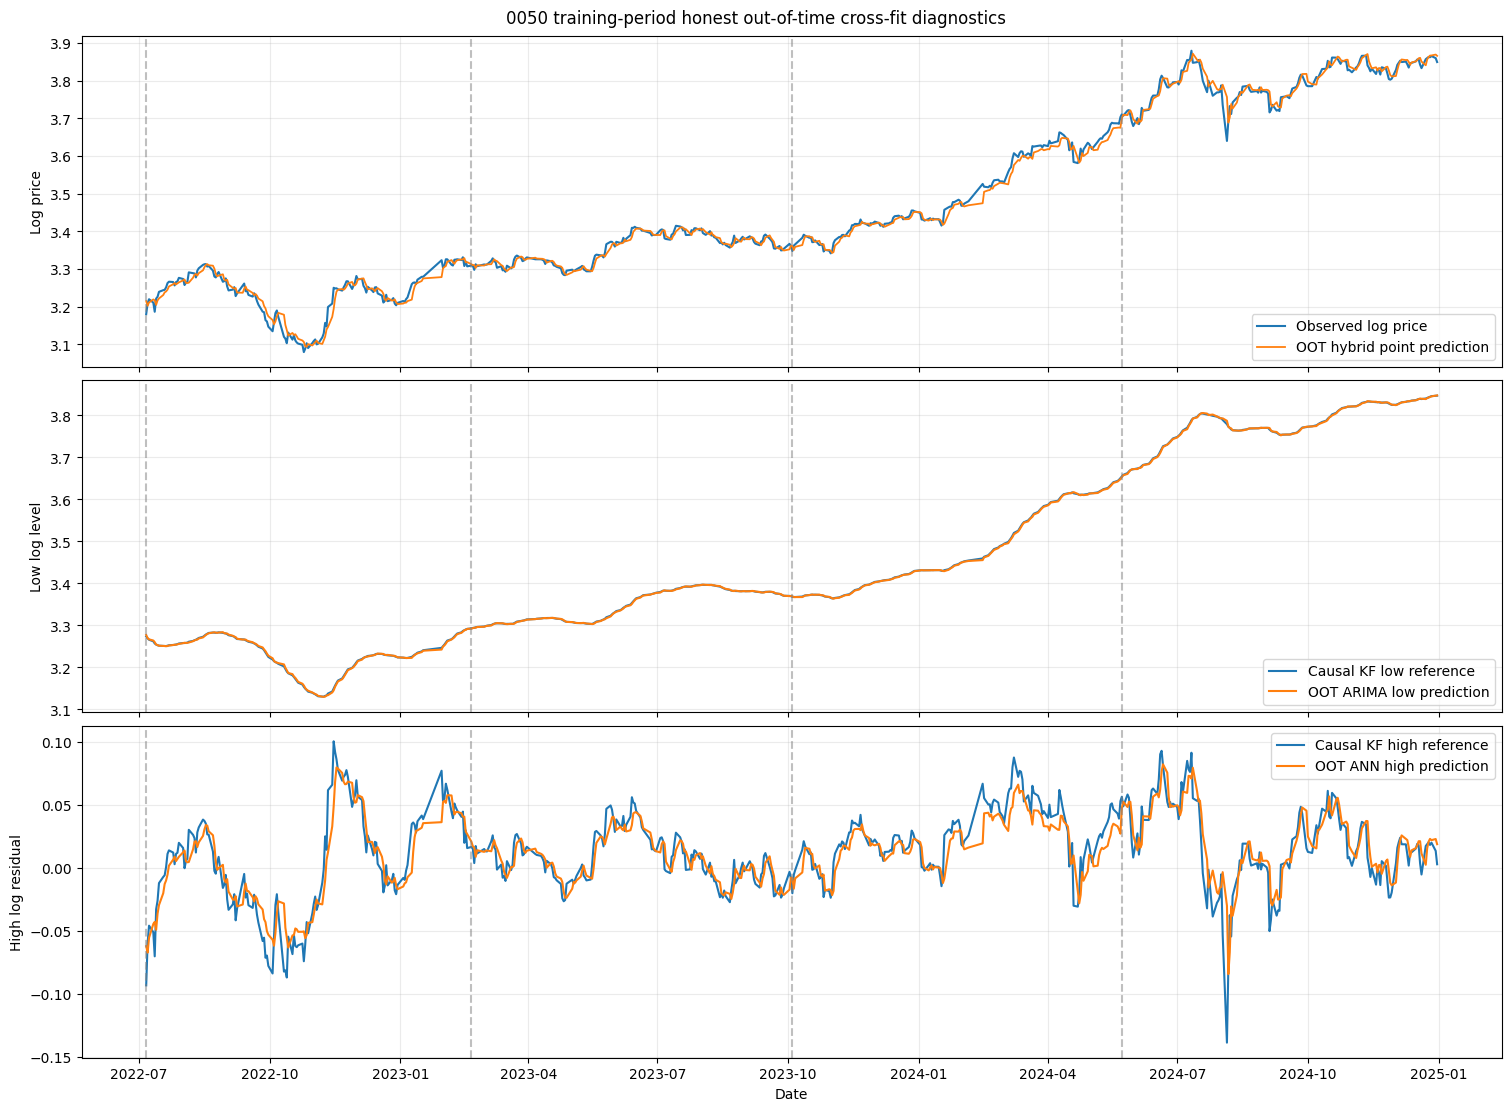

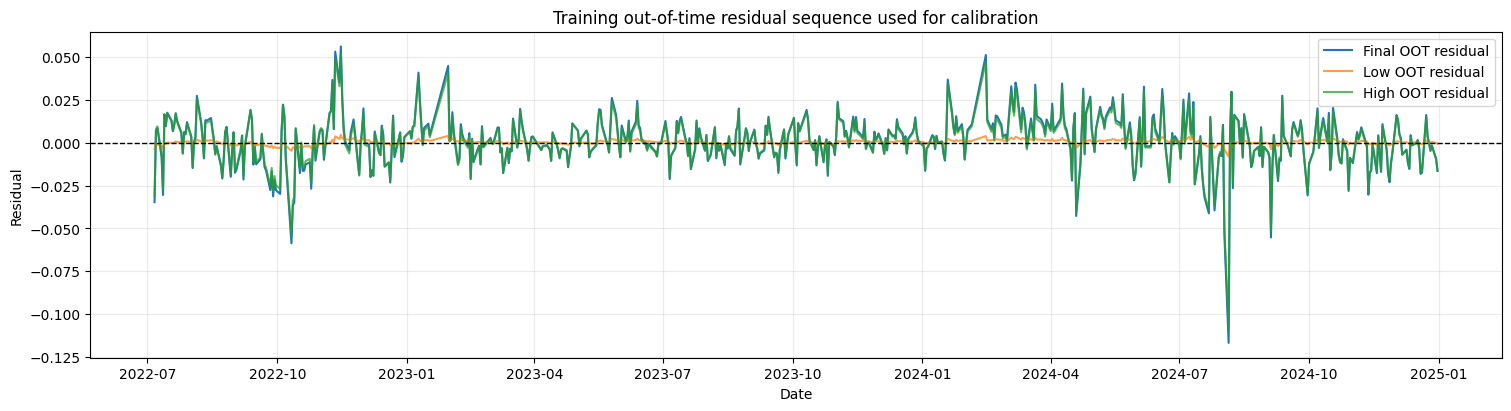

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True, constrained_layout=True)
fig.suptitle('0050 training-period honest out-of-time cross-fit diagnostics')
axes[0].plot(crossfit['date'], crossfit['truth'], label='Observed log price', linewidth=1.5)
axes[0].plot(crossfit['date'], crossfit['final_point'], label='OOT hybrid point prediction', linewidth=1.3)
axes[0].set_ylabel('Log price')
axes[0].legend(loc='best')
axes[1].plot(crossfit['date'], crossfit['low_reference'], label='Causal KF low reference')
axes[1].plot(crossfit['date'], crossfit['low_point'], label='OOT ARIMA low prediction')
axes[1].set_ylabel('Low log level')
axes[1].legend(loc='best')
axes[2].plot(crossfit['date'], crossfit['high_reference'], label='Causal KF high reference')
axes[2].plot(crossfit['date'], crossfit['high_point'], label='OOT ANN high prediction')
axes[2].set_ylabel('High log residual')
axes[2].set_xlabel('Date')
axes[2].legend(loc='best')
for _, row in fold_summary.iterrows():
    boundary = market_data['train_dates'][int(row['validation_start'])]
    for axis in axes:
        axis.axvline(boundary, color='gray', linestyle='--', alpha=0.5)
for axis in axes:
    axis.grid(alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(15, 4), constrained_layout=True)
ax.plot(crossfit['date'], crossfit['final_residual'], label='Final OOT residual')
ax.plot(crossfit['date'], crossfit['low_residual'], alpha=0.75, label='Low OOT residual')
ax.plot(crossfit['date'], crossfit['high_residual'], alpha=0.75, label='High OOT residual')
ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Training out-of-time residual sequence used for calibration')
ax.set_xlabel('Date')
ax.set_ylabel('Residual')
ax.grid(alpha=0.25)
ax.legend(loc='best')
plt.show()

## 6. Training-only adaptive residual-window 選擇

候選 $W$ 只用 training cross-fit residual sequence 的後段做 prequential interval-score 比較；分數越低越好。這個選擇結果才會作為 final test 的初始殘差池長度。

,window,window_value,mean_interval_score,coverage,mean_width,n_validation_residuals,validation_start_position,selected
0,all,NaN,0.1079,0.9012,0.0553,243,364,True
1,400,400.0,0.1111,0.8765,0.0517,243,364,False
2,100,100.0,0.1167,0.8971,0.0525,243,364,False
3,200,200.0,0.1224,0.8642,0.0504,243,364,False
4,300,300.0,0.1271,0.8560,0.0486,243,364,False


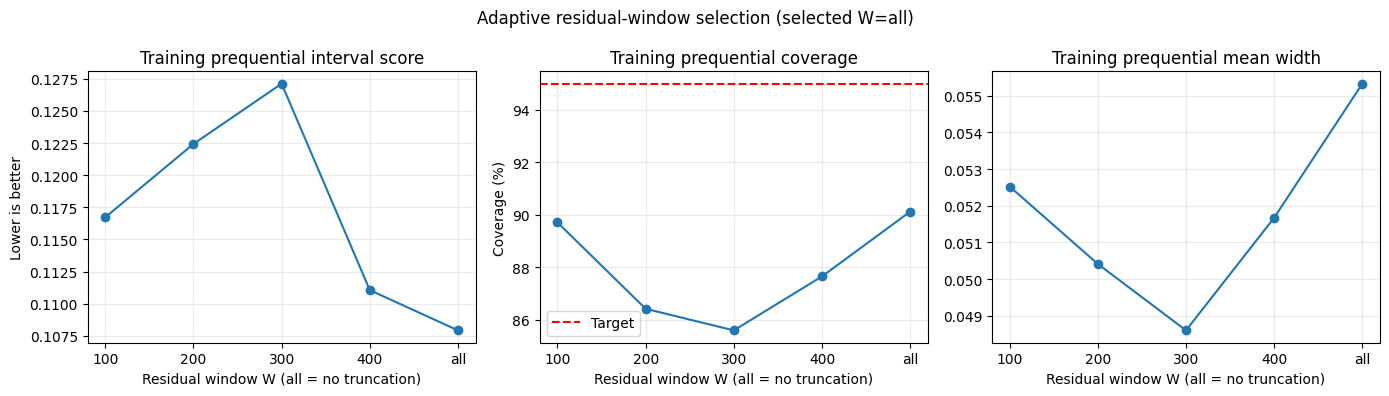

In [8]:
display(out_of_time_result.window_selection)
plot_window_selection(out_of_time_result)
plt.show()

## 7. 日期對齊的最終五圖

第三、四圖的區間分別以 low/high OOT residual pool 校準，供分支診斷；第五圖才是研究目標的 final interval，它由觀測 log price 減去合併後 hybrid OOT prediction 所得的 final residual pool 校準。

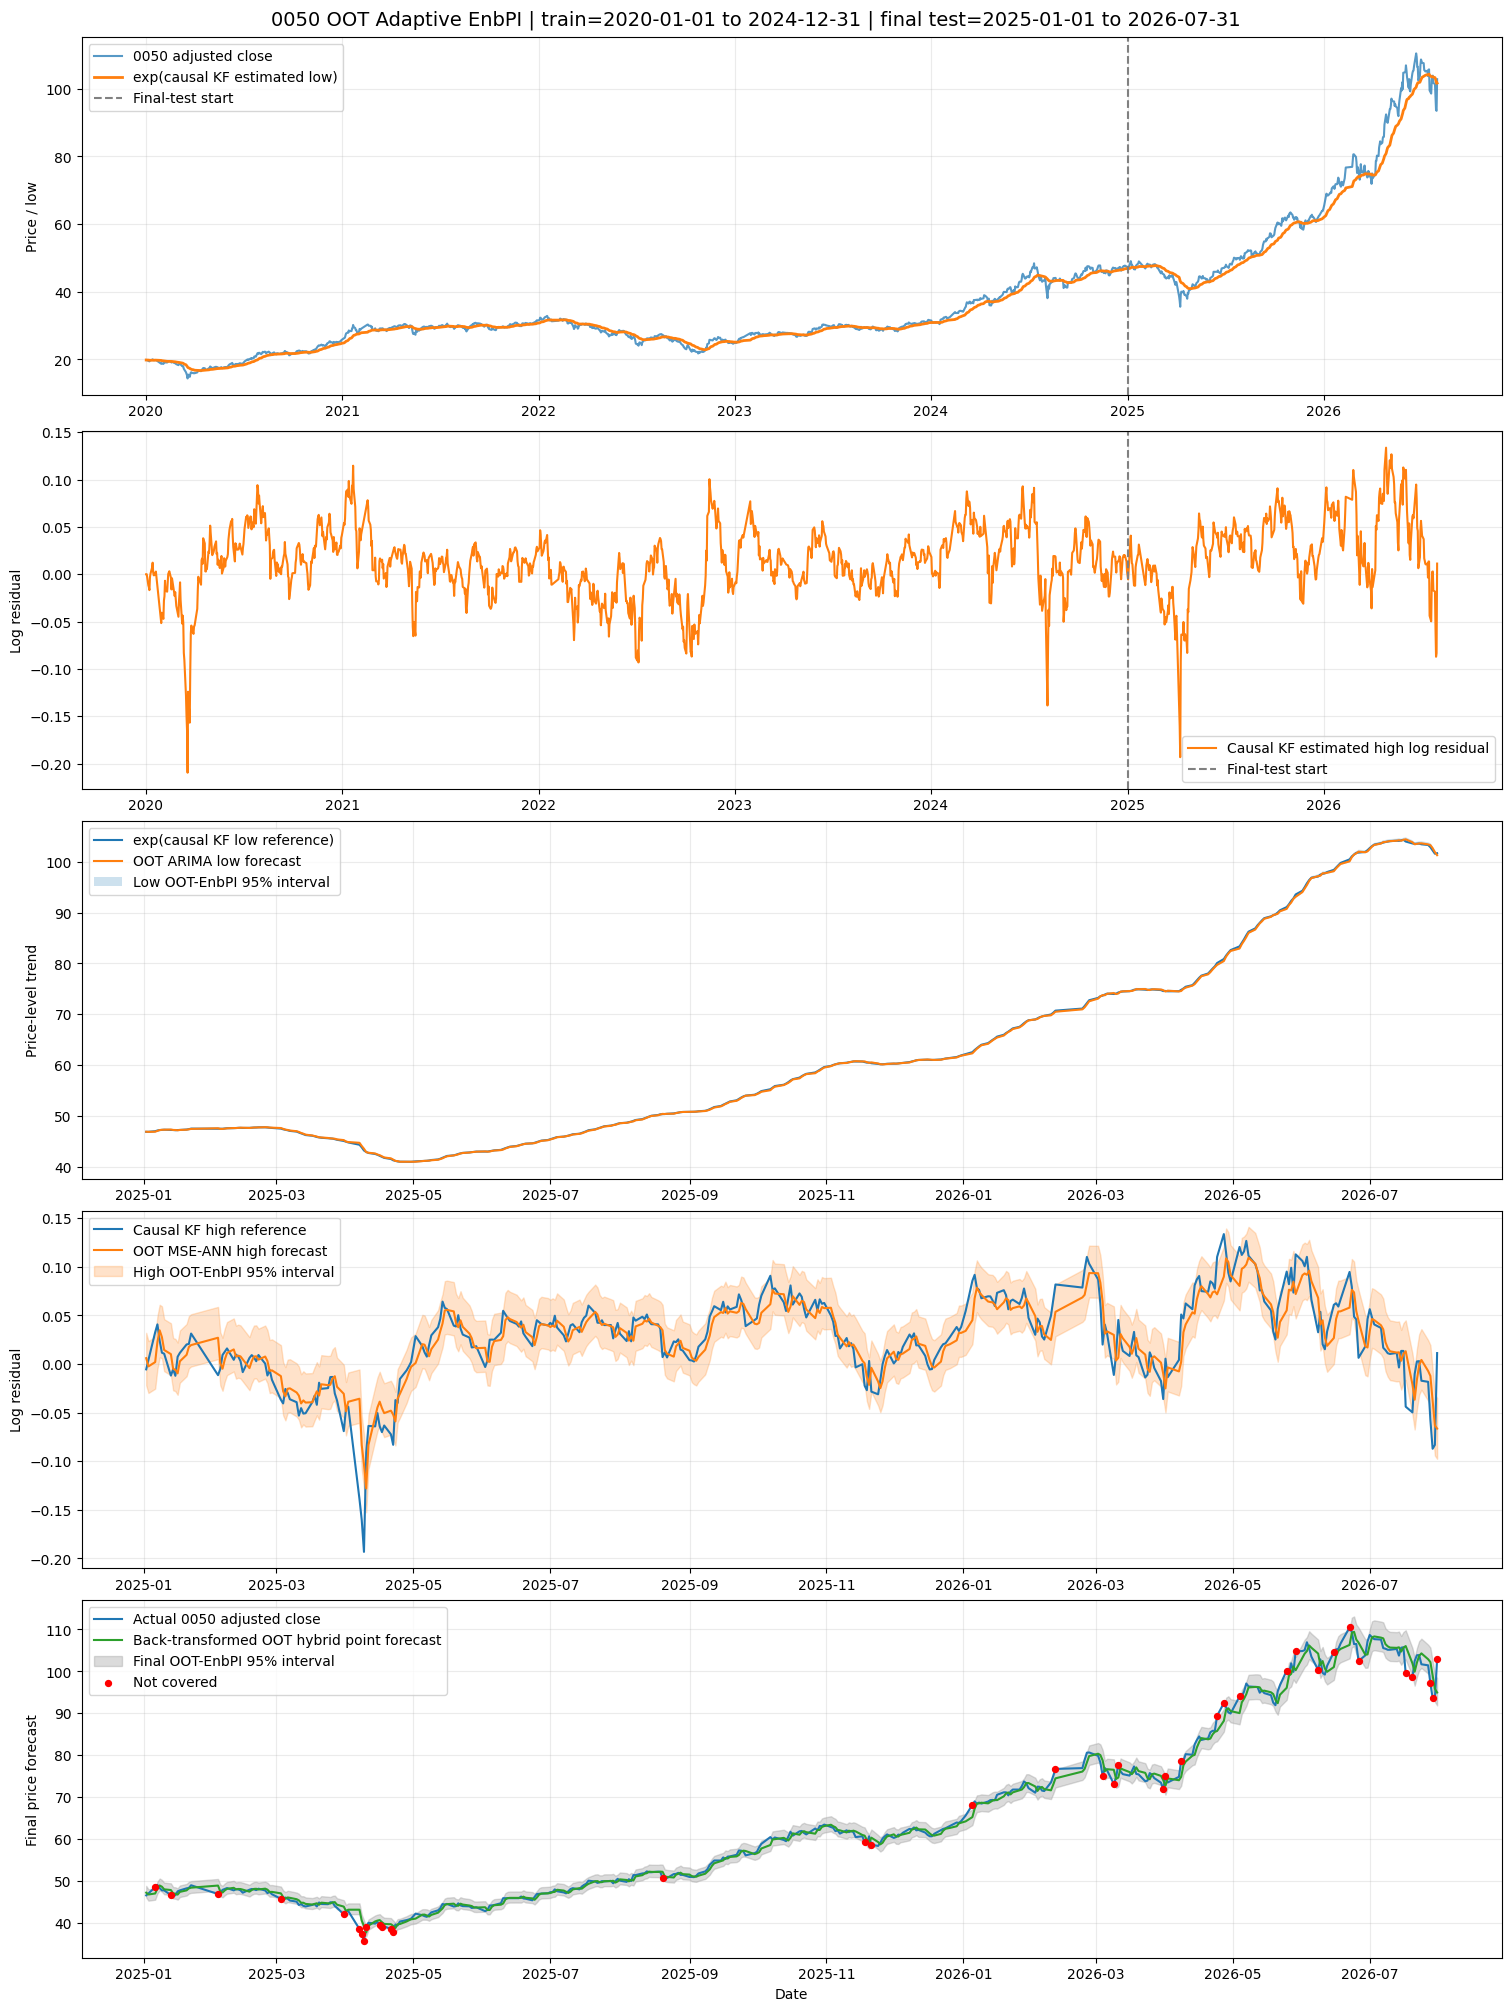

In [9]:
full_dates = market_data['full_dates']
forecast_start = test_dates[0]
frame = result.frame()

fig, axes = plt.subplots(5, 1, figsize=(15, 20), constrained_layout=True)
fig.suptitle(
    f"0050 OOT Adaptive EnbPI | train={market_data['train_period']} | final test={market_data['test_period']}",
    fontsize=14,
)

axes[0].plot(full_dates, market_data['full_price_series'], label='0050 adjusted close', alpha=0.75)
axes[0].plot(full_dates, np.exp(result.estimated_low), label='exp(causal KF estimated low)', linewidth=2)
axes[0].axvline(forecast_start, color='gray', linestyle='--', label='Final-test start')
axes[0].set_ylabel('Price / low')
axes[0].legend(loc='best')

axes[1].plot(full_dates, result.estimated_high, color='tab:orange', label='Causal KF estimated high log residual')
axes[1].axvline(forecast_start, color='gray', linestyle='--', label='Final-test start')
axes[1].set_ylabel('Log residual')
axes[1].legend(loc='best')

axes[2].plot(test_dates, np.exp(frame['low_reference']), label='exp(causal KF low reference)')
axes[2].plot(test_dates, np.exp(frame['low_point']), label='OOT ARIMA low forecast')
axes[2].fill_between(
    test_dates, np.exp(frame['low_lower']), np.exp(frame['low_upper']), alpha=0.22,
    label='Low OOT-EnbPI 95% interval',
)
axes[2].set_ylabel('Price-level trend')
axes[2].legend(loc='best')

axes[3].plot(test_dates, frame['high_reference'], label='Causal KF high reference')
axes[3].plot(test_dates, frame['high_point'], label='OOT MSE-ANN high forecast')
axes[3].fill_between(
    test_dates, frame['high_lower'], frame['high_upper'], color='tab:orange', alpha=0.22,
    label='High OOT-EnbPI 95% interval',
)
axes[3].set_ylabel('Log residual')
axes[3].legend(loc='best')

axes[4].plot(test_dates, price_truth, label='Actual 0050 adjusted close')
axes[4].plot(test_dates, price_point, color='tab:green', label='Back-transformed OOT hybrid point forecast')
axes[4].fill_between(
    test_dates, price_lower, price_upper, color='gray', alpha=0.28,
    label='Final OOT-EnbPI 95% interval',
)
miss = ~price_covered
axes[4].scatter(test_dates[miss], price_truth[miss], color='red', s=18, zorder=4, label='Not covered')
axes[4].set_ylabel('Final price forecast')
axes[4].set_xlabel('Date')
axes[4].legend(loc='best')

for axis in axes:
    axis.grid(alpha=0.25)
plt.show()

## 8. Final-test 涵蓋率、寬度與誤差診斷

除了整段 final-test coverage，也畫出逐期累積涵蓋與 20 個交易日 rolling coverage。Rolling coverage 只作事後診斷，不回頭調整模型或 $W$。

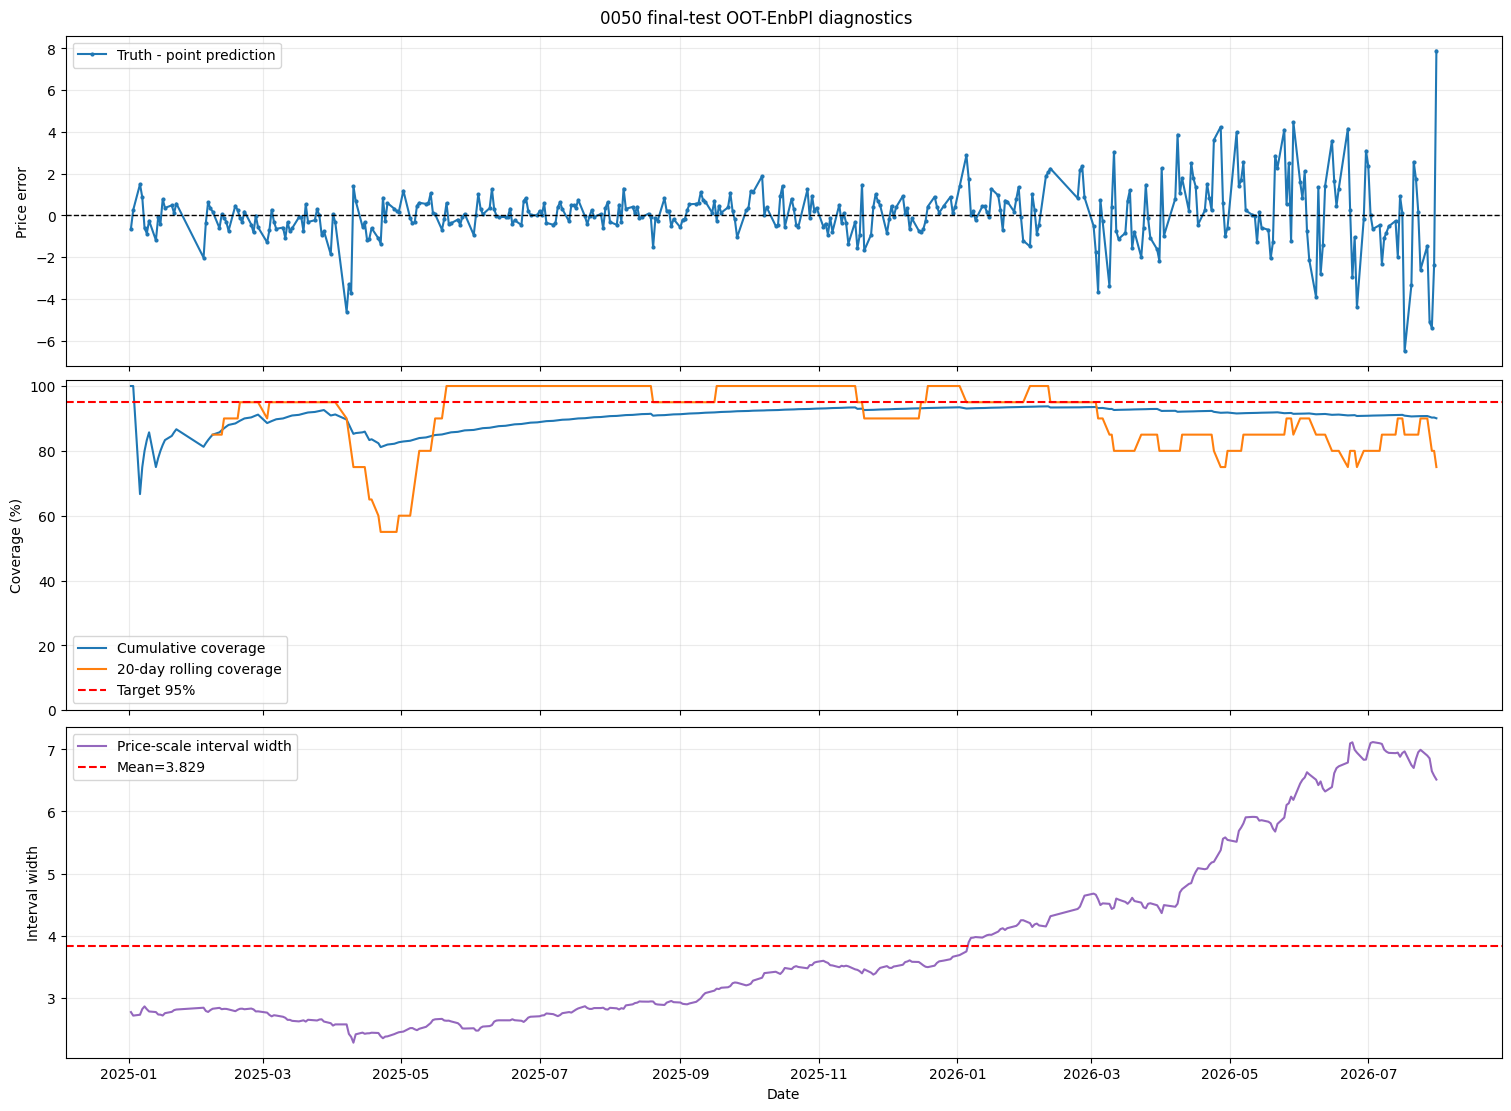

In [10]:
rolling_window = min(20, max(5, horizon // 5))
coverage_series = pd.Series(price_covered.astype(float), index=test_dates)
rolling_coverage = coverage_series.rolling(rolling_window, min_periods=rolling_window).mean()
cumulative_coverage = coverage_series.expanding().mean()
price_width = price_upper - price_lower

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True, constrained_layout=True)
fig.suptitle('0050 final-test OOT-EnbPI diagnostics')
axes[0].plot(test_dates, price_error, marker='o', markersize=2, label='Truth - point prediction')
axes[0].axhline(0.0, color='black', linestyle='--', linewidth=1)
axes[0].set_ylabel('Price error')
axes[0].legend(loc='best')
axes[1].plot(test_dates, 100.0 * cumulative_coverage, label='Cumulative coverage')
axes[1].plot(test_dates, 100.0 * rolling_coverage, label=f'{rolling_window}-day rolling coverage')
axes[1].axhline(100.0 * (1.0 - base_config.alpha), color='red', linestyle='--', label='Target 95%')
axes[1].set_ylim(0, 102)
axes[1].set_ylabel('Coverage (%)')
axes[1].legend(loc='best')
axes[2].plot(test_dates, price_width, color='tab:purple', label='Price-scale interval width')
axes[2].axhline(np.mean(price_width), color='red', linestyle='--', label=f'Mean={np.mean(price_width):.3f}')
axes[2].set_ylabel('Interval width')
axes[2].set_xlabel('Date')
axes[2].legend(loc='best')
for axis in axes:
    axis.grid(alpha=0.25)
plt.show()

## 9. Training OOT residual-versus-fitted 診斷

斜率與相關係數用來檢查殘差是否仍隨 fitted value 系統性改變。這裡使用真正 future-block cross-fit 產生的 fitted value 與 residual，而不是舊版 nested OOB 陣列。第二張圖把 final residual 分別對合併前的 low/high prediction 作圖，用來觀察哪個分支仍與最終誤差相關。

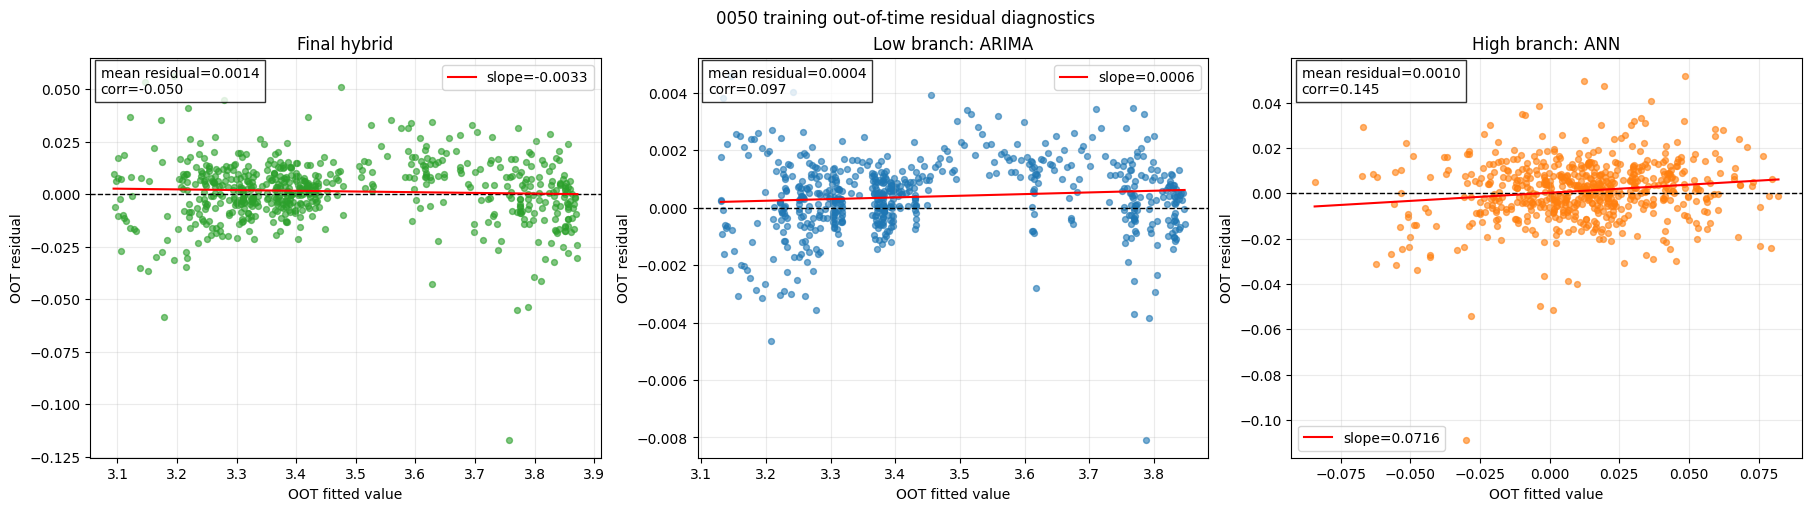

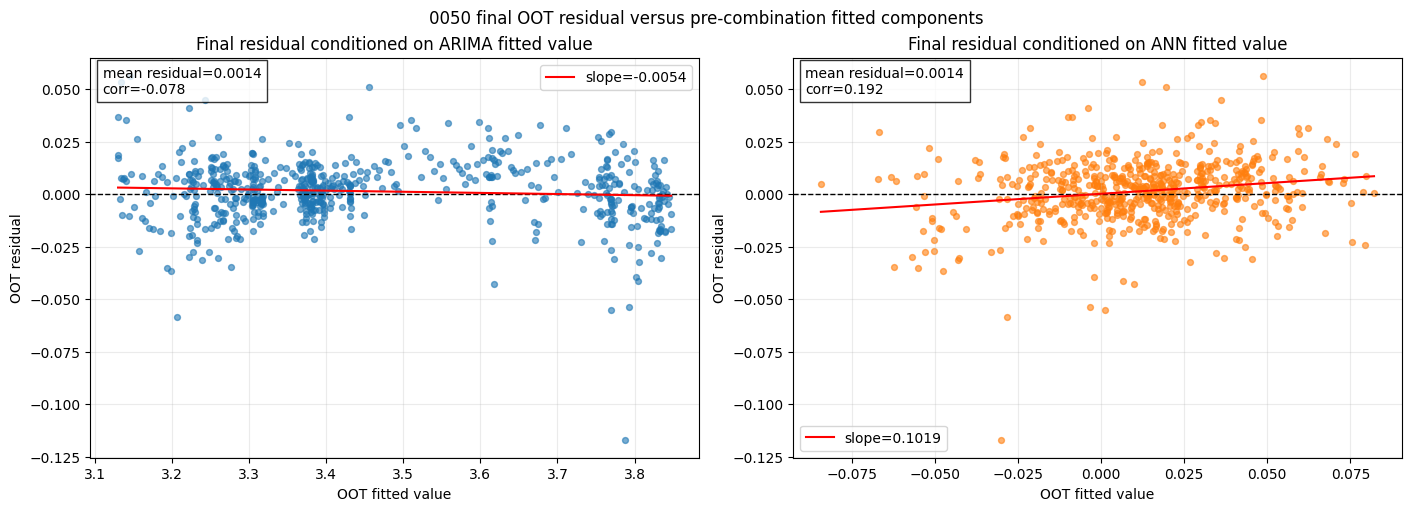

In [11]:
def residual_panel(axis, fitted, residual, title, color):
    fitted = np.asarray(fitted, dtype=float)
    residual = np.asarray(residual, dtype=float)
    axis.scatter(fitted, residual, s=18, alpha=0.60, color=color)
    axis.axhline(0.0, color='black', linestyle='--', linewidth=1)
    corr = float(np.corrcoef(fitted, residual)[0, 1]) if np.std(fitted) > 0 else np.nan
    if np.std(fitted) > 0:
        slope, intercept = np.polyfit(fitted, residual, 1)
        grid = np.linspace(fitted.min(), fitted.max(), 100)
        axis.plot(grid, intercept + slope * grid, color='red', label=f'slope={slope:.4f}')
    axis.set_title(title)
    axis.set_xlabel('OOT fitted value')
    axis.set_ylabel('OOT residual')
    axis.text(
        0.02, 0.98, f'mean residual={np.mean(residual):.4f}\ncorr={corr:.3f}',
        transform=axis.transAxes, va='top',
        bbox={'facecolor': 'white', 'alpha': 0.8},
    )
    axis.grid(alpha=0.25)
    axis.legend(loc='best')

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
fig.suptitle('0050 training out-of-time residual diagnostics')
residual_panel(axes[0], crossfit['final_point'], crossfit['final_residual'], 'Final hybrid', 'tab:green')
residual_panel(axes[1], crossfit['low_point'], crossfit['low_residual'], 'Low branch: ARIMA', 'tab:blue')
residual_panel(axes[2], crossfit['high_point'], crossfit['high_residual'], 'High branch: ANN', 'tab:orange')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
fig.suptitle('0050 final OOT residual versus pre-combination fitted components')
residual_panel(axes[0], crossfit['low_point'], crossfit['final_residual'], 'Final residual conditioned on ARIMA fitted value', 'tab:blue')
residual_panel(axes[1], crossfit['high_point'], crossfit['final_residual'], 'Final residual conditioned on ANN fitted value', 'tab:orange')
plt.show()

## 10. 解讀原則

1. 最終研究結論以 adjusted-price 的 RMSE、coverage 與 width 為主；log 與 component 指標用來診斷。
2. Low/high coverage 是相對 causal KF component，不是真實不可觀測成分的涵蓋率。
3. Adaptive $W$ 是用 training OOT residual 選出；final test 的 rolling coverage 只能用來報告，不能再用來回頭挑 $W$。
4. 本 notebook 只有一條 0050 路徑與一次固定 seed 實驗，不把它稱作 Monte Carlo。若日後要檢查穩健性，應另外使用預先指定的多個 rolling-origin final-test periods。